In [161]:
import pandas as pd
import matplotlib.pyplot as plt

In [162]:
# Datei importieren und Struktur analysieren
csv = r"Student_Performance (1).csv"
df = pd.read_csv(csv)
df.info()
# Keine fehlende Werte enthalten + alle Datentypen sind korrekt

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

In [163]:
# Vorschau des DataFrames
df.head(15)


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f
5,6,19,male,public,no formal,3.8,69.6,yes,>60 min,yes,coaching,51.5,78.3,63.9,63.5,d
6,7,14,female,private,post graduate,1.8,81.6,yes,30-60 min,no,textbook,41.9,29.4,39.2,39.1,f
7,8,18,female,private,post graduate,5.6,59.4,yes,>60 min,yes,group study,56.7,60.1,53.4,69.6,d
8,9,15,other,private,high school,3.2,89.6,yes,15-30 min,yes,mixed,54.1,59.5,38.3,55.2,d
9,10,14,female,public,diploma,6.8,62.4,yes,>60 min,no,mixed,71.9,70.4,81.3,69.6,d


In [164]:
# Lageparameter von "overall_score" bestimmen
overall_score = df["overall_score"]

mittelwert_os = overall_score.mean()
print("Mittelwert Overall Score: ", mittelwert_os)

median_os = overall_score.median()
print("Median Overall Score: ", median_os)

modus_os = overall_score.mode()
print("Modus Overall Score: ", modus_os[0])

min_os = overall_score.min()
print("Minimum Overall Score: ", min_os)

max_os = overall_score.max()
print("Maximum Overall Score: ", max_os)

quartil = 0.25
for i in range(3):
    print(f"Quartil {i+1} ({quartil*100}%): {overall_score.quantile(quartil)}")
    quartil += 0.25


Mittelwert Overall Score:  64.006172
Median Overall Score:  64.2
Modus Overall Score:  100.0
Minimum Overall Score:  14.5
Maximum Overall Score:  100.0
Quartil 1 (25.0%): 49.0
Quartil 2 (50.0%): 64.2
Quartil 3 (75.0%): 79.0


In [165]:
# Streuung und Dispersionsparameter von Overall Score

spannweite_os = max_os - min_os
print("Spannweite: ", spannweite_os)

IQA_os = overall_score.quantile(0.75) - overall_score.quantile(0.25)
print("Interquartilabstand: ", IQA_os)

varianz_os = overall_score.var()
print("Varianz: ", varianz_os)

stabw_os = overall_score.std()
print("Standardabweichung: ", stabw_os)

ausreisser_top = overall_score.quantile(0.75) + IQA_os * 1.5
print("Ausreisser hoch: ", ausreisser_top)

ausreisser_tief = overall_score.quantile(0.25) - IQA_os * 1.5
print("Ausreisser tief: ", ausreisser_tief)

Spannweite:  85.5
Interquartilabstand:  30.0
Varianz:  358.4215527685338
Standardabweichung:  18.93202452904955
Ausreisser hoch:  124.0
Ausreisser tief:  4.0


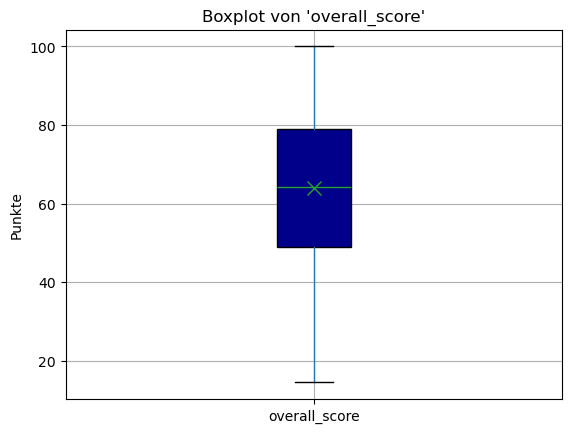

In [166]:
# Visualisierung der Daten

# Boxplot
fig, ax = plt.subplots()

df.boxplot(
    column="overall_score",
    patch_artist=True,      # erlaubt Einfärbung
    showmeans=True,
    boxprops=dict(facecolor="darkblue"),
    meanprops=dict(
        marker="x",
        markersize=10
    ),
    ax=ax
)

plt.title("Boxplot von 'overall_score'")
plt.ylabel("Punkte")

plt.show()


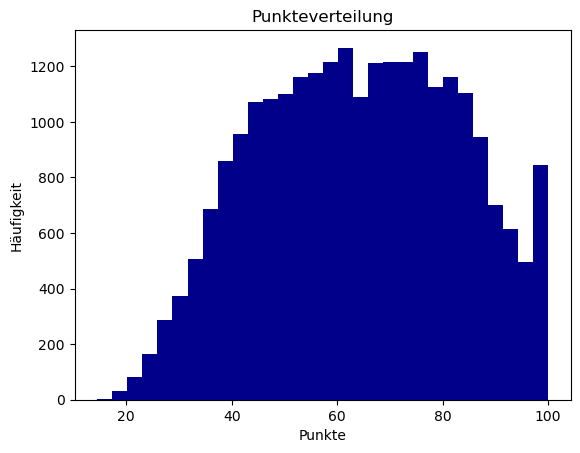

In [167]:
# Histogramm
fig, ax = plt.subplots()

overall_score.plot(
    kind="hist",
    bins=30,
    color="darkblue",
    ax=ax
)

ax.set_title("Punkteverteilung")
ax.set_xlabel("Punkte")
ax.set_ylabel("Häufigkeit")

plt.show()

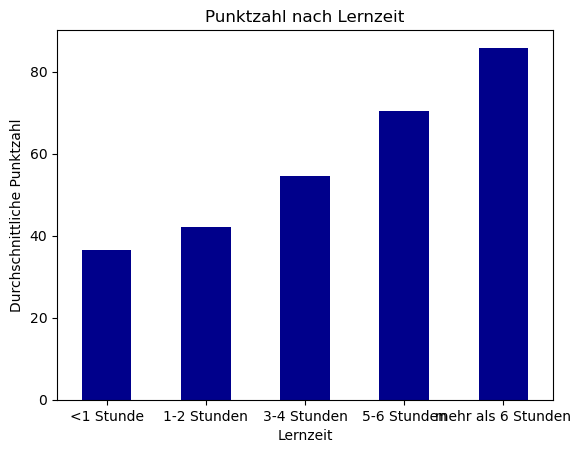

In [168]:
# Balkendiagramm
# Lernstunden in Gruppen einteilen
df["study_hours_group"] = pd.cut(
    df["study_hours"],
    bins=[0,1,2,4,6,float("inf")],
    labels=[
        "<1 Stunde",
        "1-2 Stunden",
        "3-4 Stunden",
        "5-6 Stunden",
        "mehr als 6 Stunden"
    ]
)

mittelwerte = df.groupby(
    "study_hours_group",
    observed=False
)["overall_score"].mean()

fig, ax = plt.subplots()

mittelwerte.plot(
    kind="bar",
    color="darkblue",
    ax=ax
)

ax.set_title("Punktzahl nach Lernzeit")
ax.set_xlabel("Lernzeit")
ax.set_ylabel("Durchschnittliche Punktzahl")

plt.xticks(rotation=0)

plt.show()

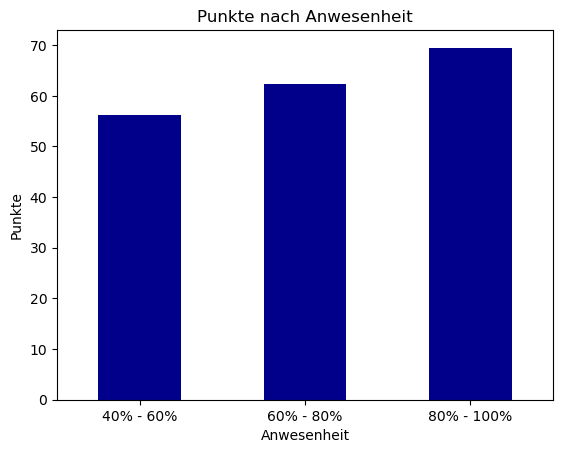

In [169]:
# Balkendiagramm
# Punkte nach Anwesenheit

df["attendance_percentage_group"] = pd.cut(
    df["attendance_percentage"],
    bins = [40, 60, 80, float("inf")],
    labels = [
    "40% - 60%",
    "60% - 80%",
    "80% - 100%"
    ]
)
mittelwerte = df.groupby(
    "attendance_percentage_group",
    observed=False
)["overall_score"].mean()

fig, ax = plt.subplots()

mittelwerte.plot(
    kind="bar",
    color="darkblue",
    ax=ax
)

ax.set_title("Punkte nach Anwesenheit")
ax.set_xlabel("Anwesenheit")
ax.set_ylabel("Punkte")

plt.xticks(rotation=0)
plt.show()

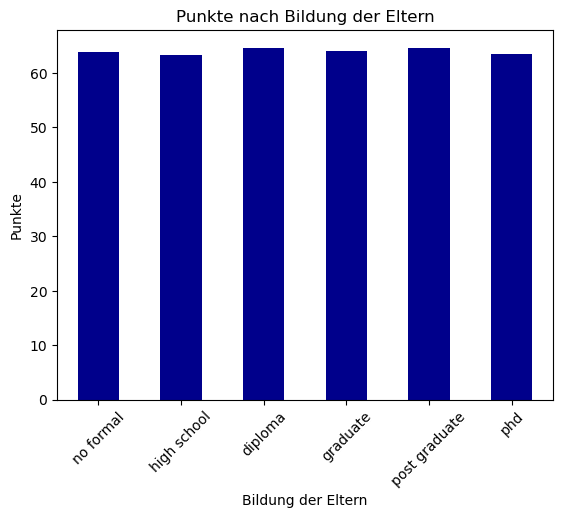

In [170]:
# Balkendiagramm
# Punkte nach Bildung der Eltern

df["parent_education_num"] = df["parent_education"].map({
    "no formal": 1,
    "high school": 2,
    "diploma": 3,
    "graduate": 4,
    "post graduate": 5,
    "phd": 6
})

df["parent_education_group"] = pd.cut(
    df["parent_education_num"],
    bins = [0, 1, 2, 3, 4, 5, 6],
    labels = [
    "no formal",
    "high school",
    "diploma",
    "graduate",
    "post graduate",
    "phd"
    ]
)

mittelwerte = df.groupby(
    "parent_education_group",
    observed=False
)["overall_score"].mean()

fig, ax = plt.subplots()

mittelwerte.plot(
    kind="bar",
    color="darkblue",
    ax=ax
)

ax.set_title("Punkte nach Bildung der Eltern")
ax.set_xlabel("Bildung der Eltern")
ax.set_ylabel("Punkte")
plt.xticks(rotation=45)
plt.show()

Korrelation:  0.9057714454088271


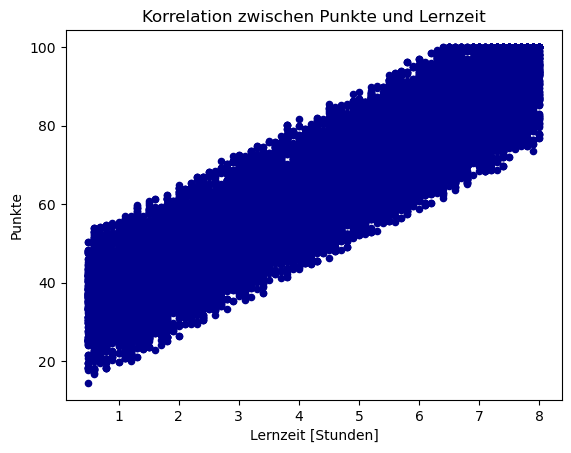

In [171]:
# Korrelation Punkte nach Lernzeit und Visualisierung
correlation = df["overall_score"].corr(df["study_hours"])
print("Korrelation: ", correlation)

fig, ax = plt.subplots()
df.plot(
    kind="scatter", 
    color="darkblue", 
    x="study_hours", 
    y="overall_score",
    ax=ax
)

ax.set_title("Korrelation zwischen Punkte und Lernzeit")
ax.set_xlabel("Lernzeit [Stunden]")
ax.set_ylabel("Punkte")
plt.show()

Korrelation:  0.29276151938517925


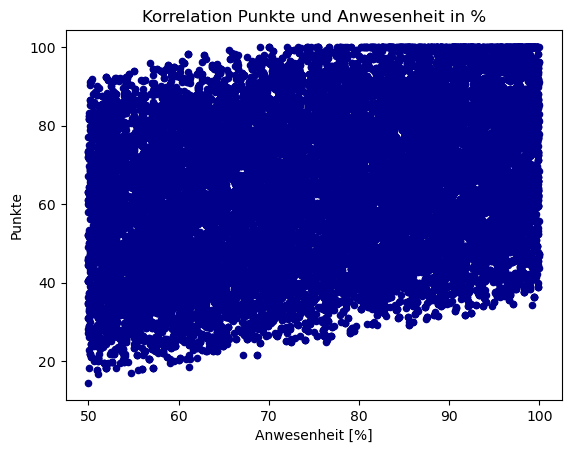

In [172]:
# Korrelation Punkte und Anwesenheit in % und Visualisierung

correlation = df["overall_score"].corr(df["attendance_percentage"])
print("Korrelation: ", correlation)

fig, ax = plt.subplots()
df.plot(
    kind="scatter",
    color="darkblue",
    x="attendance_percentage",
    y="overall_score",
    ax=ax
)

ax.set_title("Korrelation Punkte und Anwesenheit in %")
ax.set_xlabel("Anwesenheit [%]")
ax.set_ylabel("Punkte")
plt.show()

Korrelation:  0.002691873349375122


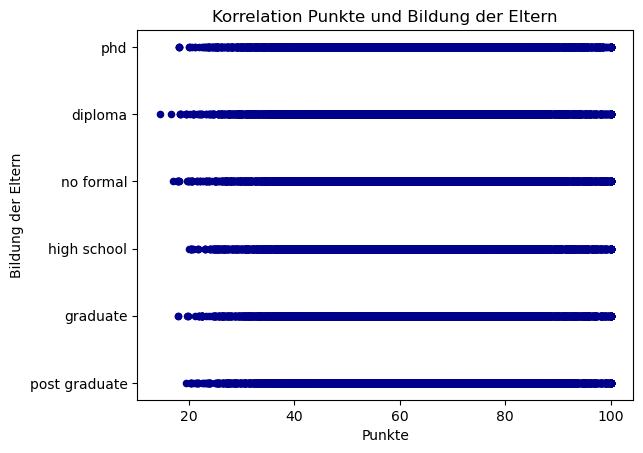

In [173]:
# Korrelation Punkte und Anwesenheit in % und Visualisierung

correlation = df["overall_score"].corr(df["parent_education_num"])
print("Korrelation: ", correlation)

fig, ax = plt.subplots()
df.plot(
    kind="scatter",
    color="darkblue",
    x="overall_score",
    y="parent_education_group",
    ax=ax
)

ax.set_title("Korrelation Punkte und Bildung der Eltern")
ax.set_xlabel("Punkte")
ax.set_ylabel("Bildung der Eltern")
plt.show()